In [1]:
import pandas as pd
import numpy as np
import anndata
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import scanpy as sc
import scvelo as scv

In [3]:
import sys
sys.path.append('../src/')

In [4]:
import MoFlow as mf

In [6]:
adata_out = anndata.read_h5ad('../data/HSPC/adata_moflow.h5ad')

In [7]:
celldancer = anndata.read_h5ad('../data/HSPC/adata_celldancer.h5ad')

In [8]:
scvelo = anndata.read_h5ad('../data/HSPC/adata_scvelo.h5ad')

In [9]:
multivelo = anndata.read_h5ad('../data/HSPC/adata_multivelo.h5ad')

In [10]:
import matplotlib
matplotlib.rcParams.update({'font.size': 12})
matplotlib.rcParams.update({'figure.facecolor': 'white'})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['svg.fonttype'] = 'none'

matplotlib.rcParams['ytick.labelright'] = False
matplotlib.rcParams['ytick.labelleft'] = True
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['ytick.left'] = True

saving figure to file ../figures/fig8A_moflow.svg


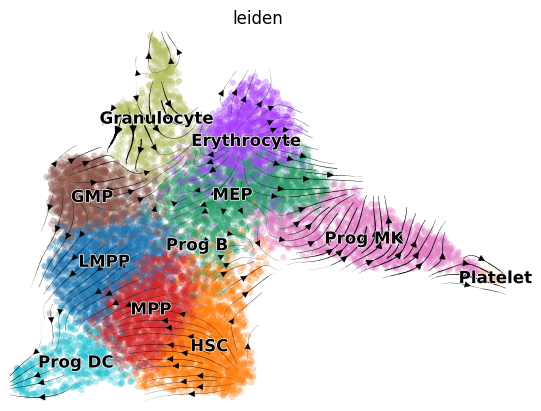

In [11]:
scv.pl.velocity_embedding_stream(adata_out, vkey='velo_s_norm', color='leiden',
                                save='../figures/fig8A_moflow.svg')


saving figure to file ../figures/fig8A_scvelo.svg


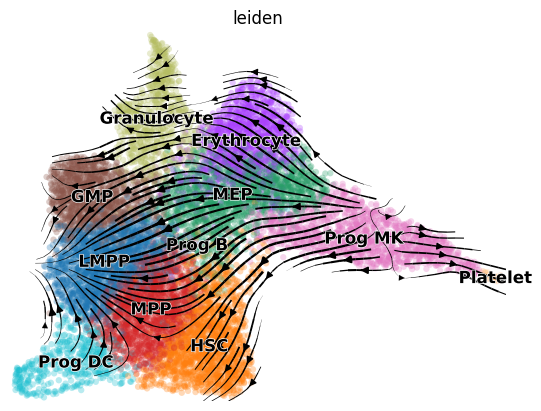

In [13]:
scv.pl.velocity_embedding_stream(scvelo,
                                 color='leiden',
                                save='../figures/fig8A_scvelo.svg')


saving figure to file ../figures/fig8A_celldancer.svg


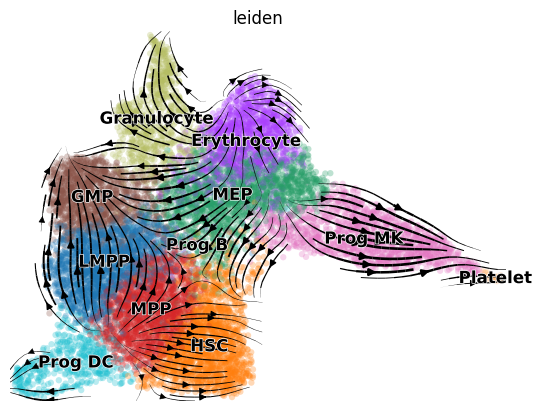

In [14]:
scv.pl.velocity_embedding_stream(celldancer,
                                 vkey='velo_s', color='leiden',
                                save='../figures/fig8A_celldancer.svg')


saving figure to file ../figures/fig8A_multivelo.svg


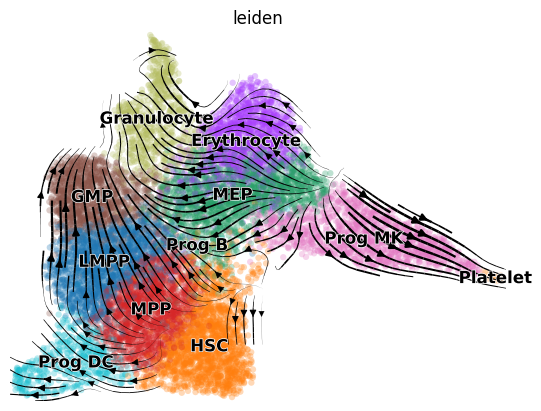

In [15]:
scv.pl.velocity_embedding_stream(multivelo,
                                 vkey='velo_s_norm', 
                                 color='leiden',
                                save='../figures/fig8A_multivelo.svg')


In [16]:
cluster_edges = (('HSC', 'MPP'), ('MPP', 'LMPP'),
                 ('LMPP', 'Prog DC'), ('LMPP', 'Prog B'),
                 ('MPP', 'MEP'),  ('MPP', 'GMP'), 
                 ('GMP', 'Granulocyte'), 
                 ('MEP', 'Prog MK'), ('Prog MK', 'Platelet'),
                ('MEP', 'Erythrocyte'))

In [17]:
cbdir = {}


In [18]:
cbdir['moflow'] = mf.cross_boundary_correctness(adata_out, 'leiden', 'velo_s_norm', cluster_edges,
                                          True, 'X_umap')
cbdir['scvelo'] = mf.cross_boundary_correctness(scvelo, 'leiden', 'velocity', cluster_edges,
                                          True, 'X_umap')
cbdir['celldancer'] = mf.cross_boundary_correctness(celldancer, 'leiden', 'velo_s', cluster_edges,
                                          True, 'X_umap')
cbdir['multivelo'] = mf.cross_boundary_correctness(multivelo, 'leiden', 'velo_s_norm', cluster_edges,
                                          True, 'X_umap')

In [19]:
cbdir_ = []
for k in cbdir.values():
    temp = {}
    for c, s in k.items():
        s = np.mean(s)
        temp[c] = s
    cbdir_.append(temp)
    
cbdir_ = pd.DataFrame(cbdir_, index=cbdir.keys())

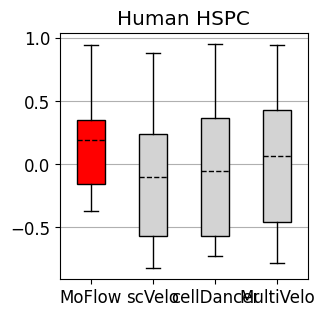

In [21]:
fig, ax = plt.subplots(figsize=(3.2, 3.2))
bplot = ax.boxplot(cbdir_.T,
            medianprops=dict(linewidth=0),
            meanline=True, 
            showmeans=True, 
            #width=.5, 
            meanprops=dict(color='black'), 
            patch_artist=True,
            showfliers=False)
colors = ['red', 'lightgrey', 'lightgrey', 'lightgrey']
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color=color)
ax.set_xticklabels(['MoFlow', 'scVelo', 'cellDancer', 'MultiVelo'])
plt.title('Human HSPC')
plt.grid(axis='y')
fig.savefig('../figures/fig8B_cbdir.pdf')